# __DATA VISUALIZATION ON ELECTRIC POWER SOURCES (1995-2024)__

### This dataset presents annual installed power generation capacity by energy sources from 1995 to 2024, covering conventional, renewable, and waste-based sources for trend and comparison analysis.

## **READING AND PREPARING THE DATA**

In [2]:
## Importing essential libraries in order to clean the data and visualize it
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the data
df = pd.read_csv('electric_stations_power.csv')
df

,Year,Unnamed: 1,End-year power capacity (MW),Fuel & thermal power plants (MW),Hydropower plants (MW),Wind power plants (MW),Solar power plants (MW),Municipal solid waste power plant (MW),Biogas power plants (MW)
0,2024,NaN,7115.1,5698.5,1062.3,64,257.6,32,0.7
1,2023,NaN,7907.4,6323.1,1209.4,64,266.2,44,0.7
2,2022,NaN,7976.9,6652.3,1164.7,64,51.2,44,0.7
3,2021,NaN,7965.2,6649.4,1157.2,66,47.9,44,0.7
4,2020,NaN,7621.6,6326.1,1149.4,66,35.1,44,1
5,2019,NaN,7639.2,6350.3,1144.8,66,33.1,44,1
6,2018,NaN,7828.9,6552.2,1130.8,66,34.9,44,1
7,2017,NaN,7941.5,6748.0,1106.4,15.7,28.4,42,1
8,2016,NaN,7910.4,6726.8,1105.0,15.7,24.9,37,1
9,2015,NaN,7806.7,6652.8,1103.4,7.7,4.8,37,1


## **CHECKING THE DATA**

In [3]:
df.shape               # Checking the size of dataset
df.info                # Checking the column info and non-null counts
df.isna().sum()        # Counting the NaN values in each column

Year                                       0
Unnamed: 1                                30
End-year power capacity (MW)               0
Fuel & thermal power plants (MW)           0
Hydropower plants (MW)                     0
Wind power plants (MW)                     0
Solar power plants (MW)                    0
Municipal solid waste power plant (MW)     0
Biogas power plants (MW)                   0
dtype: int64

## **DATA CLEANING PROCESS**

### Missing or placeholder values ('-') are replaced with zeros, an unnecessary 'Unnamed: 1' column is removed, and column names are shortened for clearer and more efficient data handling and analysis.

In [4]:
## Cleaning the data
# Replacing the missing values with 0
df.replace('-', 0, inplace=True)

# Deleting the second unnamed column
df.drop(columns='Unnamed: 1', axis=1, inplace=True)

# Renaming the columns by shortening for using more efficiently
df.rename(columns={'End-year power capacity (MW)': 'Total_capacity',
                   'Fuel & thermal power plants (MW)': 'Fuel-Thermal','Hydropower plants (MW)': 'Hydro',
                   'Wind power plants (MW)': 'Wind',
                   'Solar power plants (MW)': 'Solar',
                   'Municipal solid waste power plant (MW)': 'MSW',
                   'Biogas power plants (MW)': 'Biogas'
                   }, inplace=True)


In [5]:
df

,Year,Total_capacity,Fuel-Thermal,Hydro,Wind,Solar,MSW,Biogas
0,2024,7115.1,5698.5,1062.3,64,257.6,32,0.7
1,2023,7907.4,6323.1,1209.4,64,266.2,44,0.7
2,2022,7976.9,6652.3,1164.7,64,51.2,44,0.7
3,2021,7965.2,6649.4,1157.2,66,47.9,44,0.7
4,2020,7621.6,6326.1,1149.4,66,35.1,44,1
5,2019,7639.2,6350.3,1144.8,66,33.1,44,1
6,2018,7828.9,6552.2,1130.8,66,34.9,44,1
7,2017,7941.5,6748.0,1106.4,15.7,28.4,42,1
8,2016,7910.4,6726.8,1105.0,15.7,24.9,37,1
9,2015,7806.7,6652.8,1103.4,7.7,4.8,37,1


### Converting the Year and Energy Capacity columns (Wind, Solar, Hydro, Fuel-Thermal) to numeric data types to ensure correct plotting and numerical analysis.

In [6]:
df['Year'] = pd.to_numeric(df['Year'])
df['Wind'] = pd.to_numeric(df['Wind'])
df['Solar'] = pd.to_numeric(df['Solar'])
df['Hydro'] = pd.to_numeric(df['Hydro'])
df['Fuel-Thermal'] = pd.to_numeric(df['Fuel-Thermal'])

## **VISUALIZATION PART**

### The first line plot shows the change in total installed power generation capacity (MW) over time, illustrating the overall growth of the energy sector across the analyzed years.

### In terms of the description of the first graph, there is a steady rise of total energy capacity from 1995 to 2024, showing how the system has grown from roughly 5,000 MW to nearly 8,000 MW. The timeline captures a clear period of acceleration after 2012, driven largely by the rapid integration of solar and wind power into the grid. While traditional sources like biogas and municipal waste provided a consistent foundation for decades, the recent surge in renewables is what ultimately pushed the total capacity to the record highs we see in the last few years.

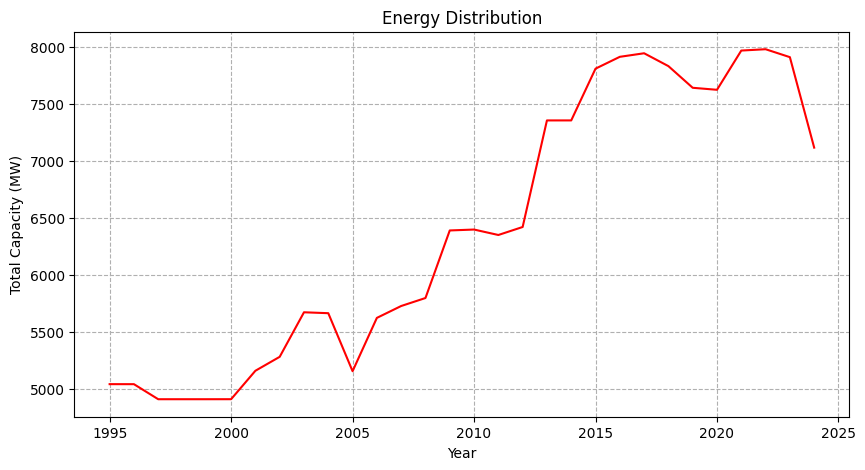

In [7]:
## Total_capacity VS Year

plt.figure(figsize= (10, 5))
plt.plot(df['Year'], df['Total_capacity'], color='red')
plt.title('Energy Distribution')
plt.xlabel('Year')
plt.ylabel('Total Capacity (MW)')
plt.grid(True, linestyle='--')
plt.show()

# Fluctuated trend over time

### This plot shows how fuel-thermal, hydro, wind, and solar power capacities have changed over time, highlighting the growth of renewable energy alongside conventional sources.



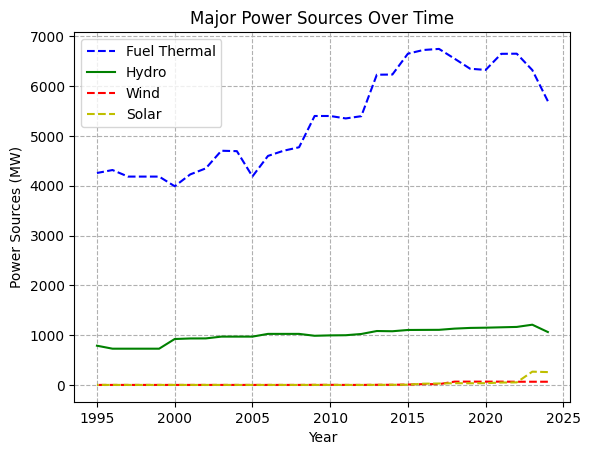

In [8]:
## Multiple line visualization
# Fuel-Thermal, Hydro, Wind, Solar VS Year

plt.plot(df['Year'], df['Fuel-Thermal'], 'b--', label='Fuel Thermal')
plt.plot(df['Year'], df['Hydro'], 'g-', label='Hydro')
plt.plot(df['Year'], df['Wind'], 'r--', label='Wind')
plt.plot(df['Year'], df['Solar'], 'y--', label='Solar')
plt.xlabel('Year')
plt.ylabel('Power Sources (MW)')
plt.title('Major Power Sources Over Time')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

### On the other hand, this horizontal grouped bar chart generated by applying seaborn compares wind, solar, municipal solid waste, and biogas power capacities from 2013 to 2024, clearly highlighting the growth of renewable sources while keeping smaller contributors visible across years.

### What charms the most is the dramatic "blue surge" of solar power; after years of being a minor player, it exploded in 2023 to become the dominant source in this category. This sudden leap creates a striking visual story of an energy grid hitting a tipping point and modernizing almost overnight.

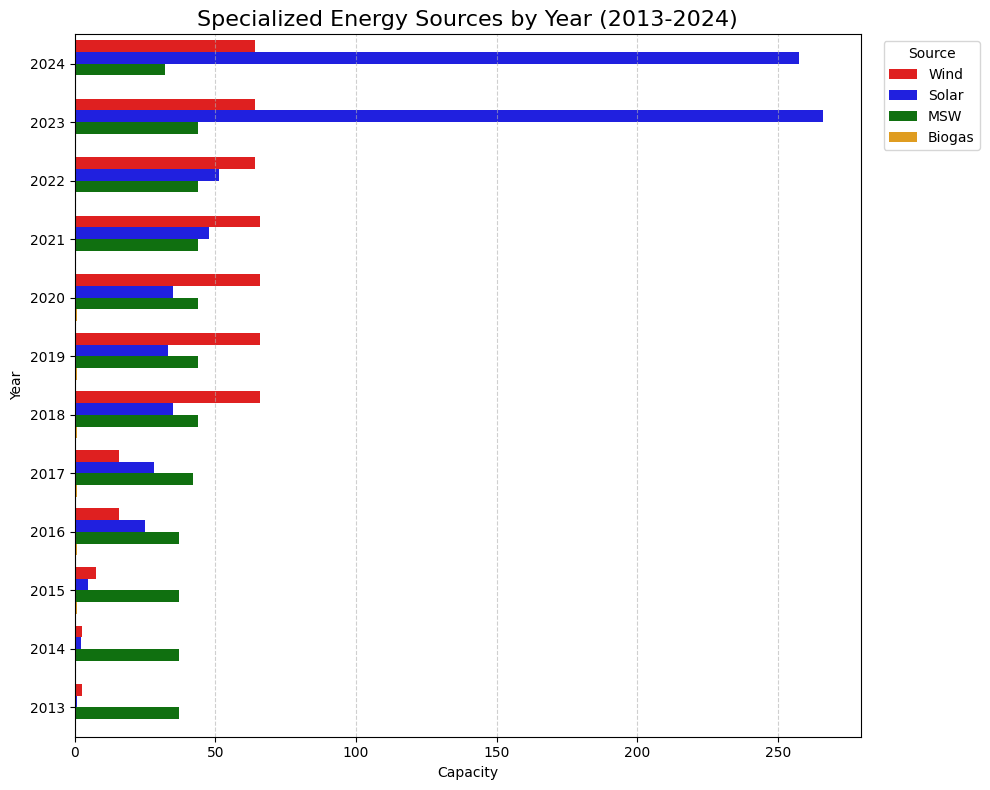

In [9]:
## Bar Chart visualization on wind, solar, municipal solid waste and biogas power plants by using SeaBorn
import seaborn as sns

# Filter dataset for years 2013-2024
df_filtered = df[(df['Year'] >= 2013) & (df['Year'] <= 2024)]
# Sort by Year descending to show 2024 at the top
df_filtered = df_filtered.sort_values('Year', ascending=False)

# Melt the data to long format for Seaborn
df_plotting = df_filtered.melt(
    id_vars='Year',
    value_vars=['Wind', 'Solar', 'MSW', 'Biogas'],
    var_name='Energy Source',
    value_name='Capacity'
)

plt.figure(figsize=(10, 8))

# Create horizontal grouped bar chart
sns.barplot(
    data=df_plotting,
    x='Capacity',                     # Numeric axis
    y=df_plotting['Year'].astype(str),# Categorical axis for grouping
    hue='Energy Source',
    dodge=True,                       # Separate bars for each source
    orient='h',                       # Horizontal bar
    palette=['red', 'blue', 'green', 'orange']
)

plt.title('Specialized Energy Sources by Year (2013-2024)', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend(title='Source', bbox_to_anchor=(1.02, 1), loc='upper left')                                  # Legend with a specific position
plt.tight_layout()
plt.show()
